# EDA — movie features and ratings

Explore distributions in `movies_features.csv`, actor/director encoding coverage, feature correlations with per-movie rating mean and std, and user-level rating patterns in `ratings.csv`.

## 1. Load

Load model-ready movie features and the ratings table. Define column groups for later plots.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROCESSED = Path("../data/processed")

movies = pd.read_csv(PROCESSED / "movies_features.csv")
ratings = pd.read_csv(PROCESSED / "ratings.csv")

print(f"movies: {movies.shape}")
print(f"ratings: {ratings.shape}")
movies.head(3)

movies: (1322, 294)
ratings: (57035791, 4)


,netflix_movie_id,tmdb_id,title,year,movie_age,runtime,budget_log,revenue_log,log_roi,budget_log_scaled,...,actor_benjamin_bratt,actor_robin_wright,actor_philip_seymour_hoffman,actor_diane_lane,actor_t_a_leoni,actor_lucy_liu,actor_john_turturro,actor_taye_diggs,actor_will_patton,actor_courteney_cox
0,30,6964,Something's Gotta Give,2003.0,23.0,128.0,18.197537,19.401743,1.204206,0.906038,...,0,0,0,0,0,0,0,0,0,0
1,55,11863,Jade,1995.0,31.0,95.0,17.727534,16.103146,-1.624388,0.619650,...,0,0,0,0,0,0,0,0,0,0
2,58,8840,Dragonheart,1996.0,30.0,103.0,17.858562,18.562765,0.704203,0.699489,...,0,0,0,0,0,0,0,0,0,0


In [2]:
ID_COLS = ["netflix_movie_id", "tmdb_id", "title"]
CONTINUOUS_COLS = [
    "year",
    "movie_age",
    "runtime",
    "budget_log",
    "revenue_log",
    "log_roi",
]

lang_cols = ["lang_en", "is_multilingual"]
genre_cols = [c for c in movies.columns if c.startswith("genre_")]
country_cols = [c for c in movies.columns if c.startswith("country_")]
company_cols = [c for c in movies.columns if c.startswith("company_")]
director_cols = [c for c in movies.columns if c.startswith("director_")]
actor_cols = [c for c in movies.columns if c.startswith("actor_")]

BINARY_FAMILIES = {
    "language": lang_cols,
    "genre": genre_cols,
    "country": country_cols,
    "company": company_cols,
    "director": director_cols,
    "actor": actor_cols,
}

for name, cols in BINARY_FAMILIES.items():
    print(f"{name}: {len(cols)} columns")

language: 2 columns
genre: 19 columns
country: 11 columns
company: 21 columns
director: 41 columns
actor: 186 columns


## 2. Movies — continuous distributions

Histograms of unscaled continuous features (`*_scaled` omitted; same shape after StandardScaler).

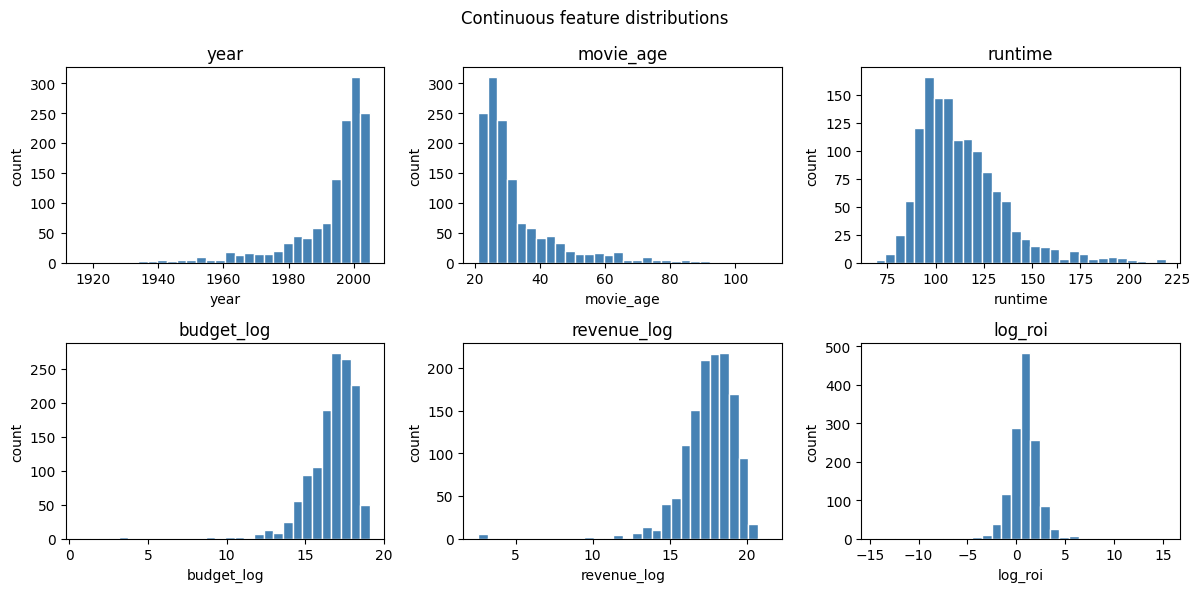

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, col in zip(axes.ravel(), CONTINUOUS_COLS):
    ax.hist(movies[col].dropna(), bins=30, color="steelblue", edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("count")
fig.suptitle("Continuous feature distributions")
fig.tight_layout()
plt.show()

## 3. Movies — binary feature counts

Bar chart per family: number of movies with each encoded column equal to 1, sorted descending.

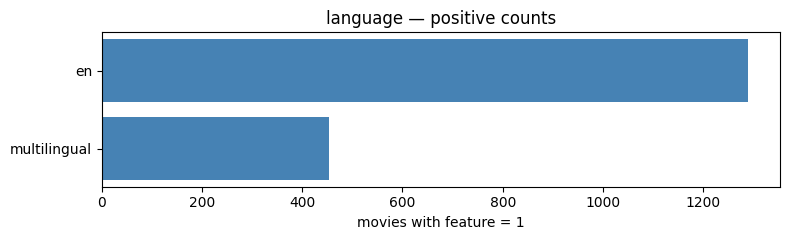

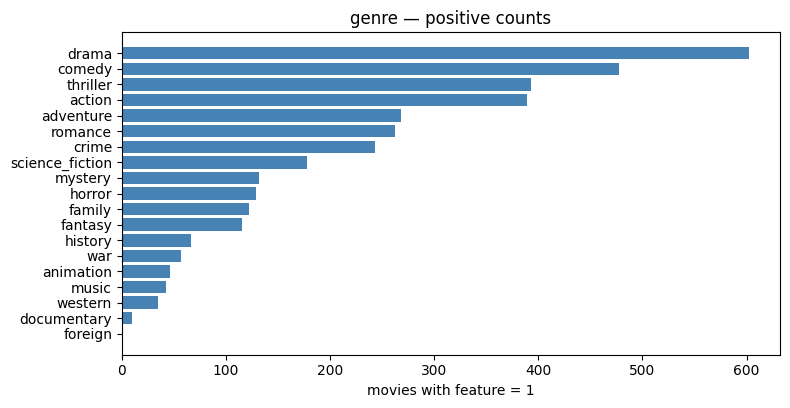

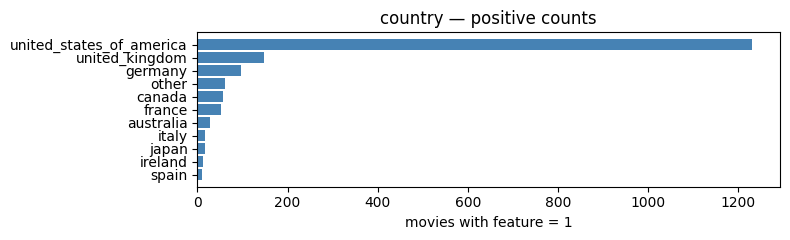

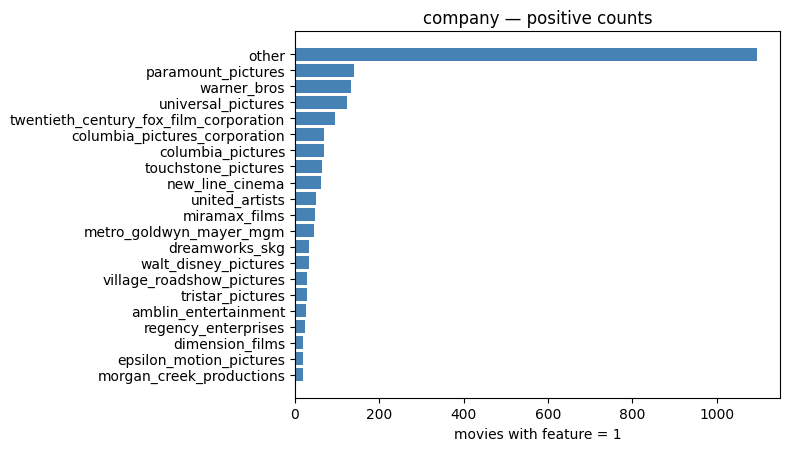

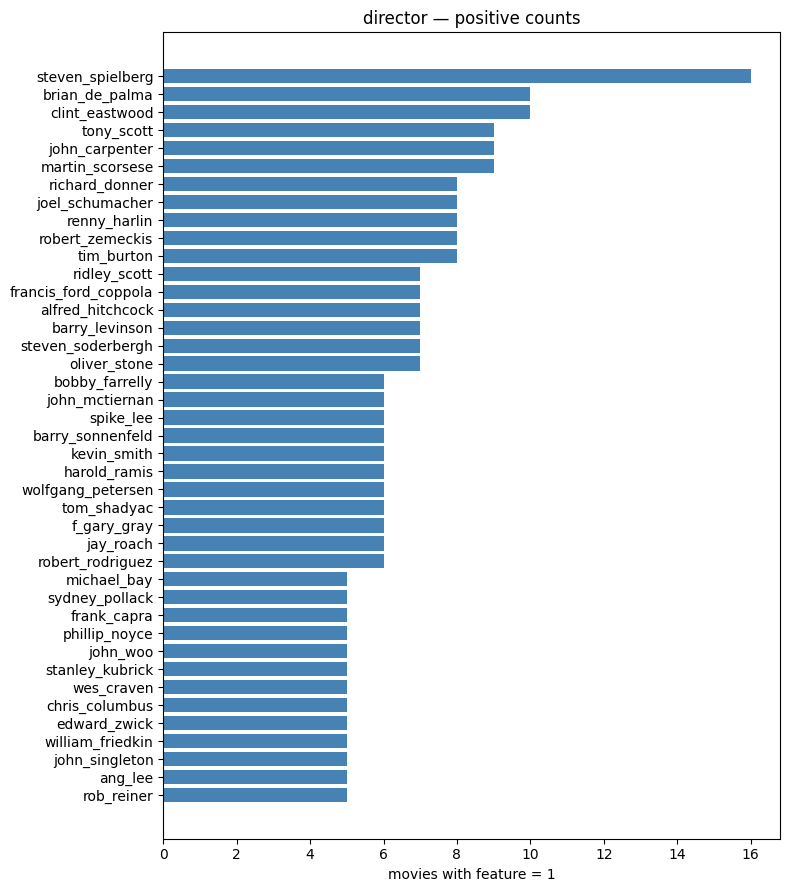

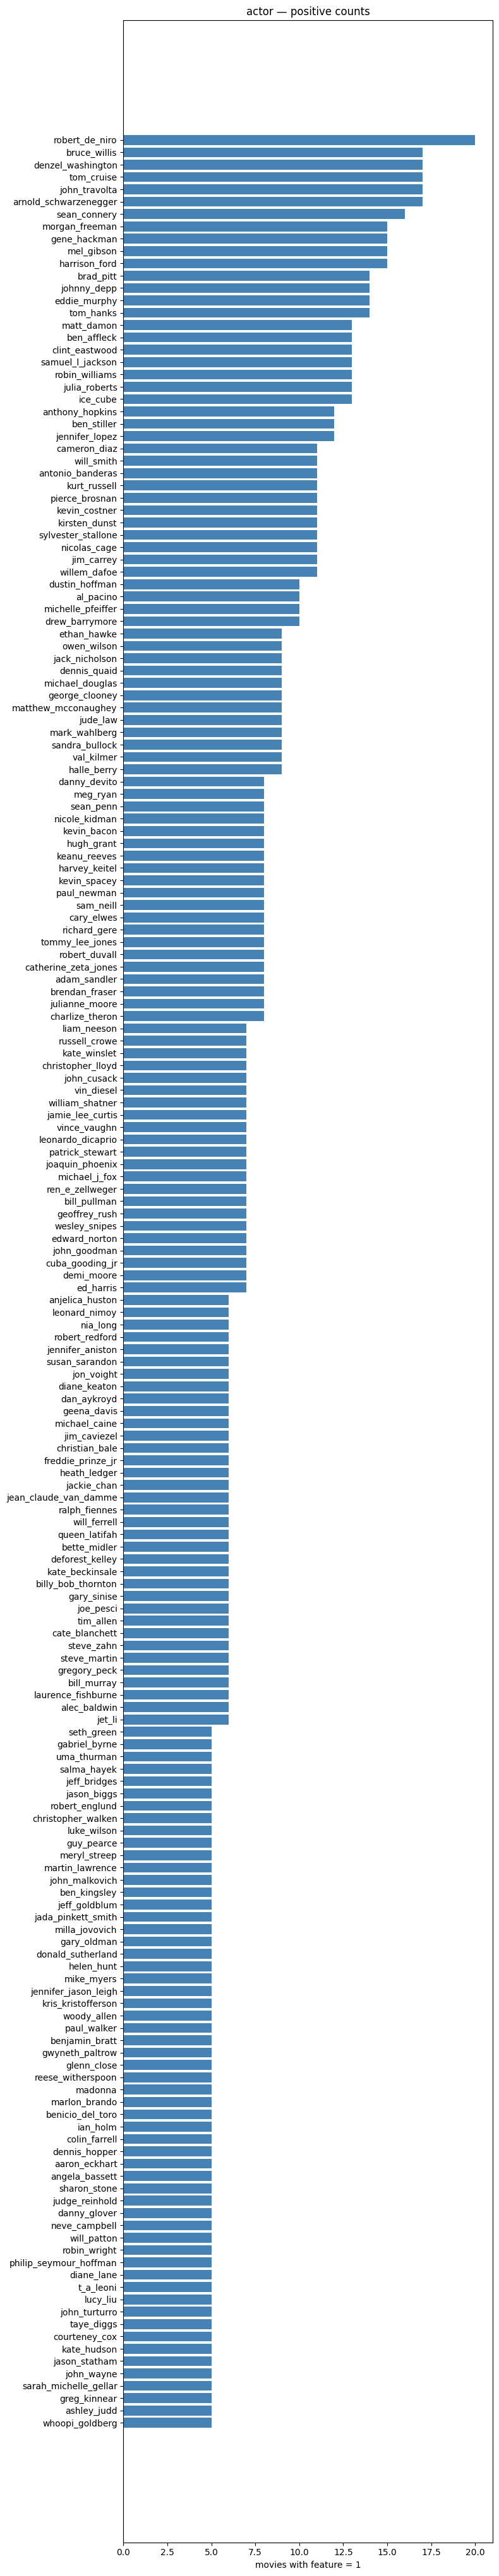

In [4]:
def plot_positive_counts(df, cols, title, figsize=None):
    counts = df[cols].sum().sort_values(ascending=True)
    labels = [c.split("_", 1)[-1] for c in counts.index]
    n = len(counts)
    if figsize is None:
        figsize = (8, max(2.5, 0.22 * n))
    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(labels, counts.values, color="steelblue")
    ax.set_xlabel("movies with feature = 1")
    ax.set_title(title)
    fig.tight_layout()
    plt.show()


for family, cols in BINARY_FAMILIES.items():
    plot_positive_counts(movies, cols, f"{family} — positive counts")

## 4. Actor / director encoding coverage

Movies with no selected actor or director one-hot set (all zeros in that family).

In [5]:
n_movies = len(movies)
no_actor = (movies[actor_cols].sum(axis=1) == 0)
no_director = (movies[director_cols].sum(axis=1) == 0)
no_both = no_actor & no_director

coverage = pd.DataFrame(
    {
        "condition": [
            "all actor_* == 0",
            "all director_* == 0",
            "both all-zero",
        ],
        "n_movies": [int(no_actor.sum()), int(no_director.sum()), int(no_both.sum())],
    }
)
coverage["pct"] = (100 * coverage["n_movies"] / n_movies).round(1)
coverage

,condition,n_movies,pct
0,all actor_* == 0,434,32.8
1,all director_* == 0,1046,79.1
2,both all-zero,378,28.6


## 5. Per-movie rating stats and feature correlations

Aggregate ratings per movie, join to features, then Spearman correlation of continuous + binary features with `avg_rating` and `rating_std`.

In [6]:
movie_rating_stats = (
    ratings.groupby("netflix_movie_id")["rating"]
    .agg(avg_rating="mean", rating_std="std", n_ratings="count")
    .reset_index()
)

movies_rated = movies.merge(movie_rating_stats, on="netflix_movie_id", how="inner")
print(f"movies with ratings: {len(movies_rated)} / {len(movies)}")
movie_rating_stats.describe()

movies with ratings: 1322 / 1322


,netflix_movie_id,avg_rating,rating_std,n_ratings
count,1806.000000,1806.000000,1806.000000,1806.000000
mean,8972.093577,3.382651,1.022081,31581.279623
std,5066.831806,0.400069,0.093226,37071.384677
min,3.000000,1.762584,0.712982,57.000000
25%,4674.750000,3.126506,0.959959,6243.000000
50%,8933.000000,3.403471,1.016043,17231.500000
75%,13318.750000,3.647497,1.081340,42361.500000
max,17764.000000,4.504660,1.378362,231697.000000


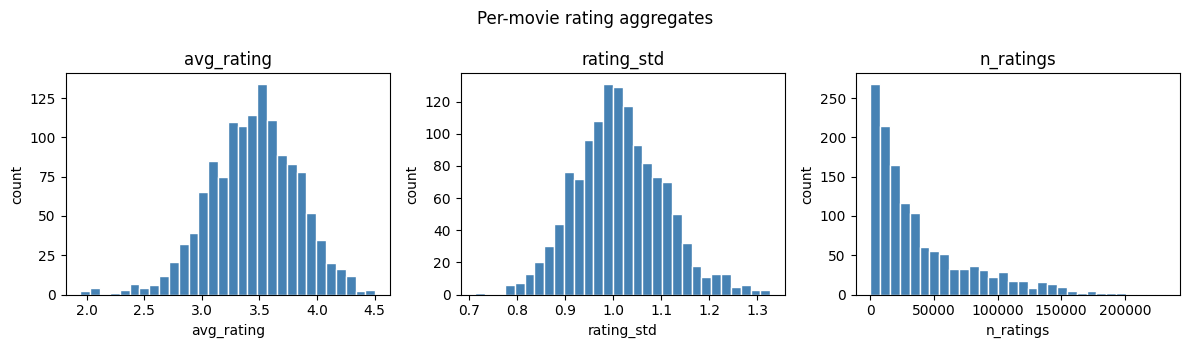

In [7]:
stat_cols = ["avg_rating", "rating_std", "n_ratings"]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, col in zip(axes, stat_cols):
    ax.hist(movies_rated[col].dropna(), bins=30, color="steelblue", edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("count")
fig.suptitle("Per-movie rating aggregates")
fig.tight_layout()
plt.show()

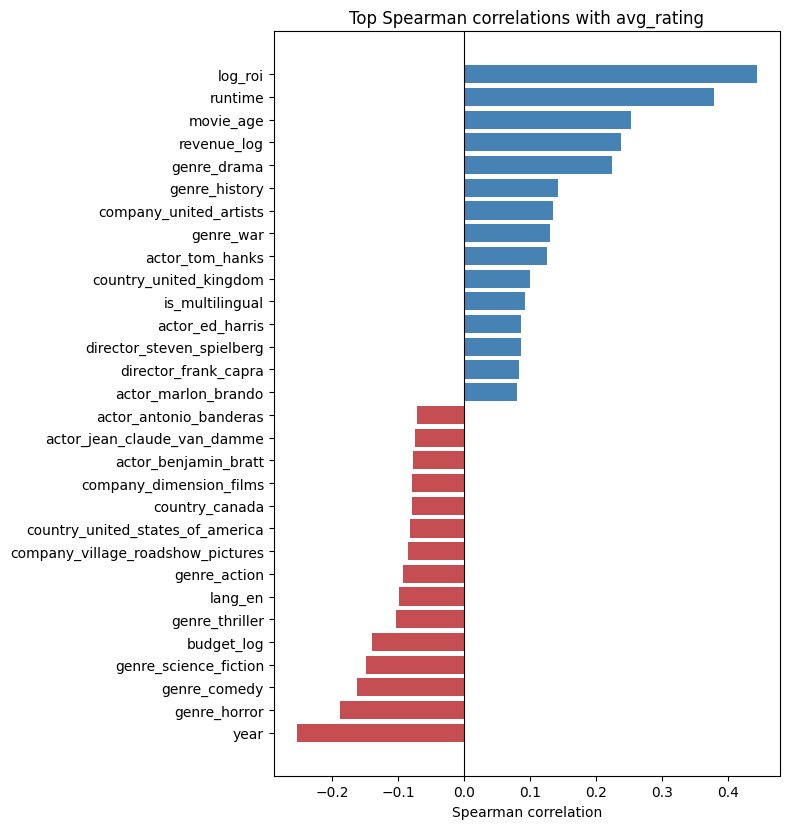

avg_rating
                                   spearman
log_roi                            0.443955
runtime                            0.378611
year                              -0.253690
movie_age                          0.253690
revenue_log                        0.238417
genre_drama                        0.224586
genre_horror                      -0.187397
genre_comedy                      -0.162100
genre_science_fiction             -0.148625
genre_history                      0.142750
budget_log                        -0.139252
company_united_artists             0.134090
genre_war                          0.130620
actor_tom_hanks                    0.126000
genre_thriller                    -0.103562
country_united_kingdom             0.099518
lang_en                           -0.099093
is_multilingual                    0.092504
genre_action                      -0.092004
actor_ed_harris                    0.086045
director_steven_spielberg          0.085977
company_village_roads

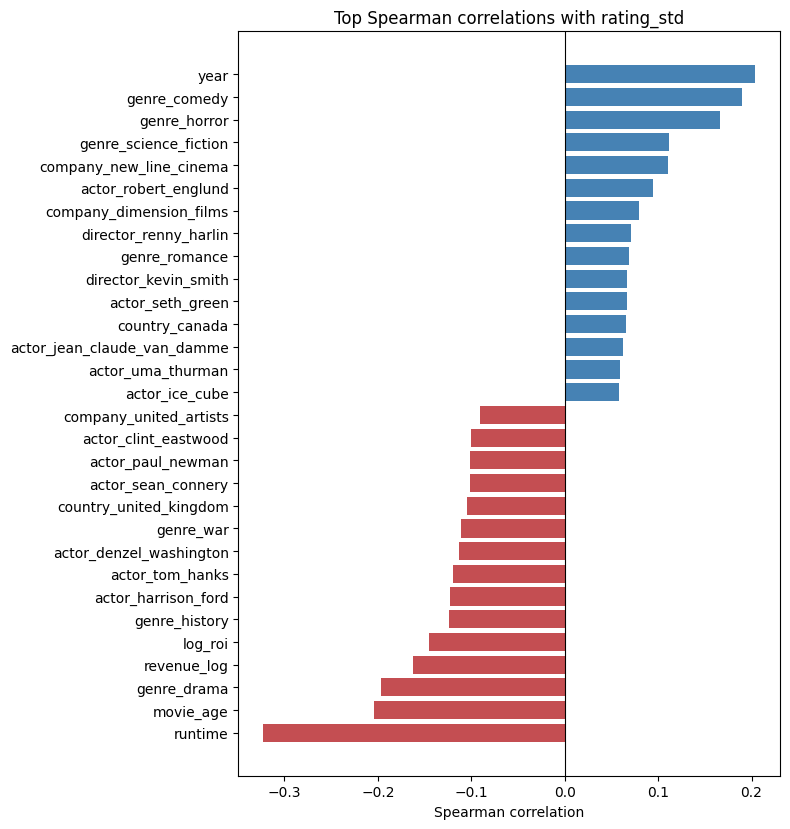

rating_std
                             spearman
runtime                     -0.322827
movie_age                   -0.204141
year                         0.204141
genre_drama                 -0.196176
genre_comedy                 0.190021
genre_horror                 0.166256
revenue_log                 -0.162673
log_roi                     -0.145267
genre_history               -0.123520
actor_harrison_ford         -0.122795
actor_tom_hanks             -0.119804
actor_denzel_washington     -0.112760
genre_science_fiction        0.112118
genre_war                   -0.111387
company_new_line_cinema      0.110777
country_united_kingdom      -0.104560
actor_sean_connery          -0.101403
actor_paul_newman           -0.101131
actor_clint_eastwood        -0.099883
actor_robert_englund         0.094823
company_united_artists      -0.091059
company_dimension_films      0.079892
director_renny_harlin        0.070564
genre_romance                0.068801
director_kevin_smith         0.066998
a

In [8]:
feature_cols = CONTINUOUS_COLS + [
    c for cols in BINARY_FAMILIES.values() for c in cols
]


def top_spearman(df, features, target, top_n=15):
    corr = df[features + [target]].corr(method="spearman")[target].drop(target)
    corr = corr.dropna().sort_values()
    bottom = corr.head(top_n)
    top = corr.tail(top_n)
    return pd.concat([bottom, top]).drop_duplicates()


def plot_corr_bars(corr_series, title):
    ordered = corr_series.sort_values()
    colors = ["#c44e52" if v < 0 else "steelblue" for v in ordered.values]
    fig, ax = plt.subplots(figsize=(8, max(3, 0.28 * len(ordered))))
    ax.barh(ordered.index, ordered.values, color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Spearman correlation")
    ax.set_title(title)
    fig.tight_layout()
    plt.show()


corr_tables = {}
for target in ["avg_rating", "rating_std"]:
    subset = movies_rated.dropna(subset=[target])
    top_corr = top_spearman(subset, feature_cols, target, top_n=15)
    plot_corr_bars(top_corr, f"Top Spearman correlations with {target}")
    corr_tables[target] = (
        top_corr.reindex(top_corr.abs().sort_values(ascending=False).index)
        .to_frame("spearman")
    )
    print(target)
    print(corr_tables[target].to_string())
    print()

## 6. Ratings — global and per-user patterns

Global score distribution, then bucketed user-level count, std, and mean rating.

users: 442,499 | median ratings/user: 70 | mean rating overall: 3.590


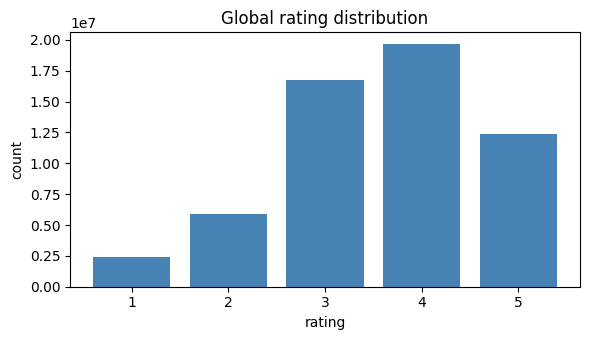

In [9]:
user_stats = ratings.groupby("customer_id")["rating"].agg(
    n_ratings="count",
    mean_rating="mean",
    rating_std="std",
)

print(
    f"users: {len(user_stats):,} | "
    f"median ratings/user: {user_stats['n_ratings'].median():.0f} | "
    f"mean rating overall: {ratings['rating'].mean():.3f}"
)

fig, ax = plt.subplots(figsize=(6, 3.5))
rating_counts = ratings["rating"].value_counts().sort_index()
ax.bar(rating_counts.index.astype(str), rating_counts.values, color="steelblue")
ax.set_xlabel("rating")
ax.set_ylabel("count")
ax.set_title("Global rating distribution")
fig.tight_layout()
plt.show()

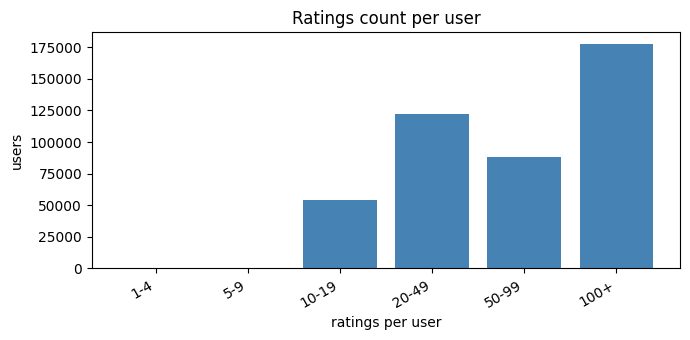

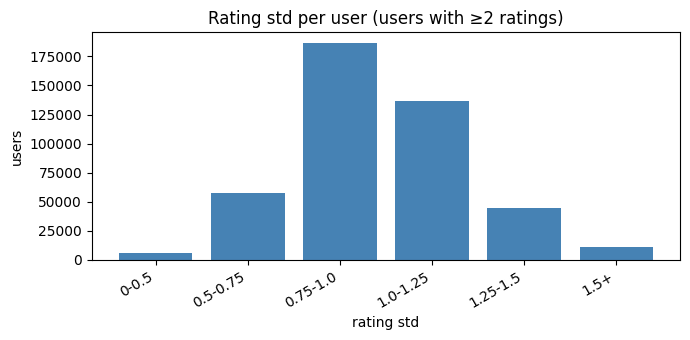

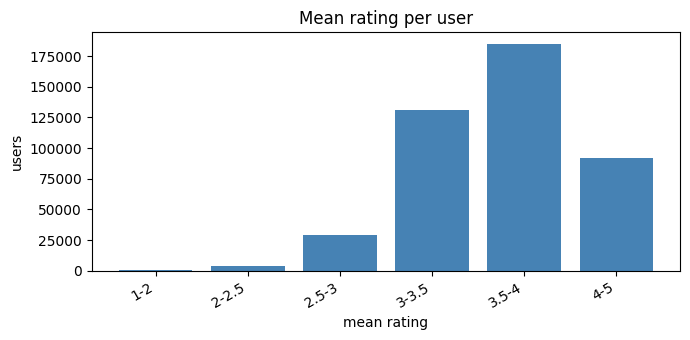

mean_rating
1-2         940
2-2.5      4164
2.5-3     29446
3-3.5    130939
3.5-4    185042
4-5       91968
Name: count, dtype: int64

In [10]:
def plot_bucket_counts(series, bins, labels, title, xlabel):
    buckets = pd.cut(series, bins=bins, labels=labels, right=True, include_lowest=True)
    counts = buckets.value_counts().reindex(labels)
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.bar(counts.index.astype(str), counts.values, color="steelblue")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("users")
    ax.set_title(title)
    plt.xticks(rotation=30, ha="right")
    fig.tight_layout()
    plt.show()
    return counts


count_bins = [0.5, 4, 9, 19, 49, 99, np.inf]
count_labels = ["1-4", "5-9", "10-19", "20-49", "50-99", "100+"]
plot_bucket_counts(
    user_stats["n_ratings"],
    bins=count_bins,
    labels=count_labels,
    title="Ratings count per user",
    xlabel="ratings per user",
)

std_users = user_stats["rating_std"].dropna()
std_bins = [-0.01, 0.5, 0.75, 1.0, 1.25, 1.5, np.inf]
std_labels = ["0-0.5", "0.5-0.75", "0.75-1.0", "1.0-1.25", "1.25-1.5", "1.5+"]
plot_bucket_counts(
    std_users,
    bins=std_bins,
    labels=std_labels,
    title="Rating std per user (users with ≥2 ratings)",
    xlabel="rating std",
)

mean_bins = [0.99, 2.0, 2.5, 3.0, 3.5, 4.0, 5.01]
mean_labels = ["1-2", "2-2.5", "2.5-3", "3-3.5", "3.5-4", "4-5"]
plot_bucket_counts(
    user_stats["mean_rating"],
    bins=mean_bins,
    labels=mean_labels,
    title="Mean rating per user",
    xlabel="mean rating",
)

## Summary

- Continuous features and binary family prevalences describe the encoded movie table.
- Actor/director all-zero rates quantify encoding coverage holes.
- Spearman links movie features to mean rating and polarization (`rating_std`).
- User buckets summarize activity, rating variance, and average score.